# SPANet HH bbtautau HDF5 Validation

This notebook checks the final SPANet HDF5 file built from reduced parquet files.

## Truth definitions used in the converter

### Source objects

The SPANet input sequence is `SPANetJet`, padded to a fixed `max_jets`. The features written to `INPUTS/Source` are `mass`, `pt`, `eta`, `phi`, and `btagDeepFlavB`. The `MASK` branch marks real jets versus padding.

### HH b jets

The Higgs-to-bb target is built from `GenPart`: select generator particles with `abs(pdgId) == 5` whose mother has `abs(pdgId) == 25`. If at least two status-23 Higgs b daughters exist, those are preferred. The two truth b quarks are matched to `SPANetJet` with `DeltaR < 0.4`, requiring two distinct reconstructed jets.

### VBF jets

The VBF target is built with the LHE-to-GenJet-to-reco path: select LHE final-state light quarks with `status == 1`, `abs(pdgId) <= 6`, and `abs(pdgId) != 5`; match the two LHE quarks to distinct `GenJet`s with `DeltaR < 0.4`; then match those `GenJet`s to distinct `SPANetJet`s with `DeltaR < 0.3`. Jets already truth-matched as HH b jets are removed before the VBF reco matching.

### Partial events

Targets that cannot be matched are stored as `-1`. The SPANet config uses `partial_events: true`, so events with only HH bb labels or only VBF labels still contribute to the corresponding assignment task.

In [1]:
from pathlib import Path
import sys

SPANET = Path('/home/norman/SPANet')
sys.path.insert(0, str(SPANET / 'utils'))

from plot_hh_bbtautau_hdf5 import load_hdf5, print_summary, make_plots, pair_kinematics, target_values

H5 = Path('/local/norman/UHHAnalysis/SPANet/hdf5/22pre_v14_vbf_signal_all.h5')
PLOT_DIR = Path('/local/norman/UHHAnalysis/SPANet/plots/22pre_v14_vbf_signal_all')

data = load_hdf5(H5)
print_summary(data)

HDF5 summary
  events: 955105
  max_jets: 16
  mean_jets: 3.48
  higgs_bb_complete: 602116/955105 (63.04%)
  vbf_complete: 369327/955105 (38.67%)
  both_complete: 212942/955105 (22.30%)
  all_four_distinct: 212942/955105 (22.30%)


In [2]:
make_plots(data, PLOT_DIR)
print(PLOT_DIR)

/local/norman/UHHAnalysis/SPANet/plots/22pre_v14_vbf_signal_all


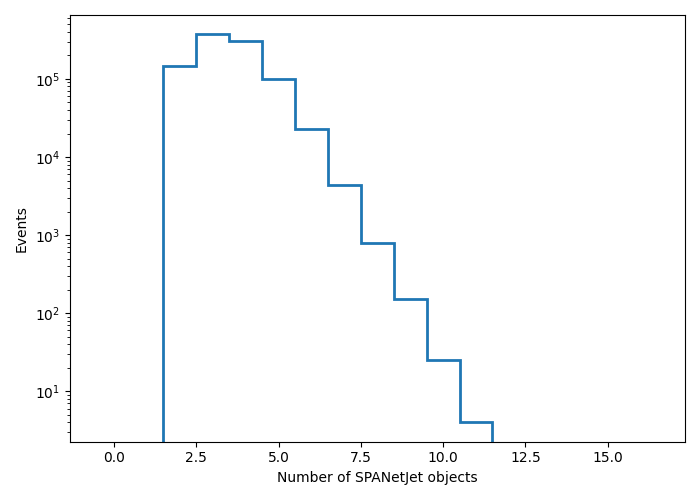

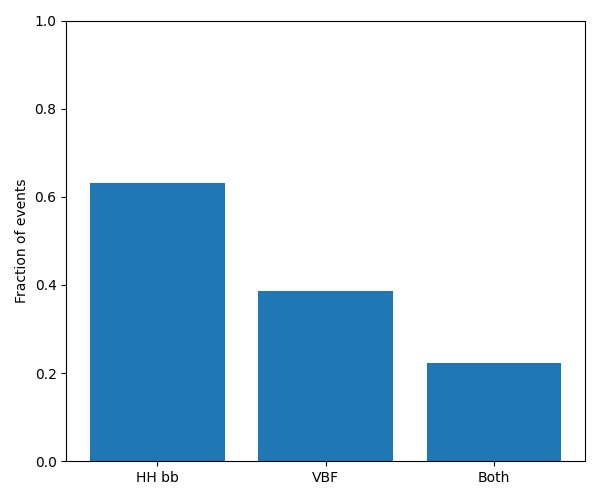

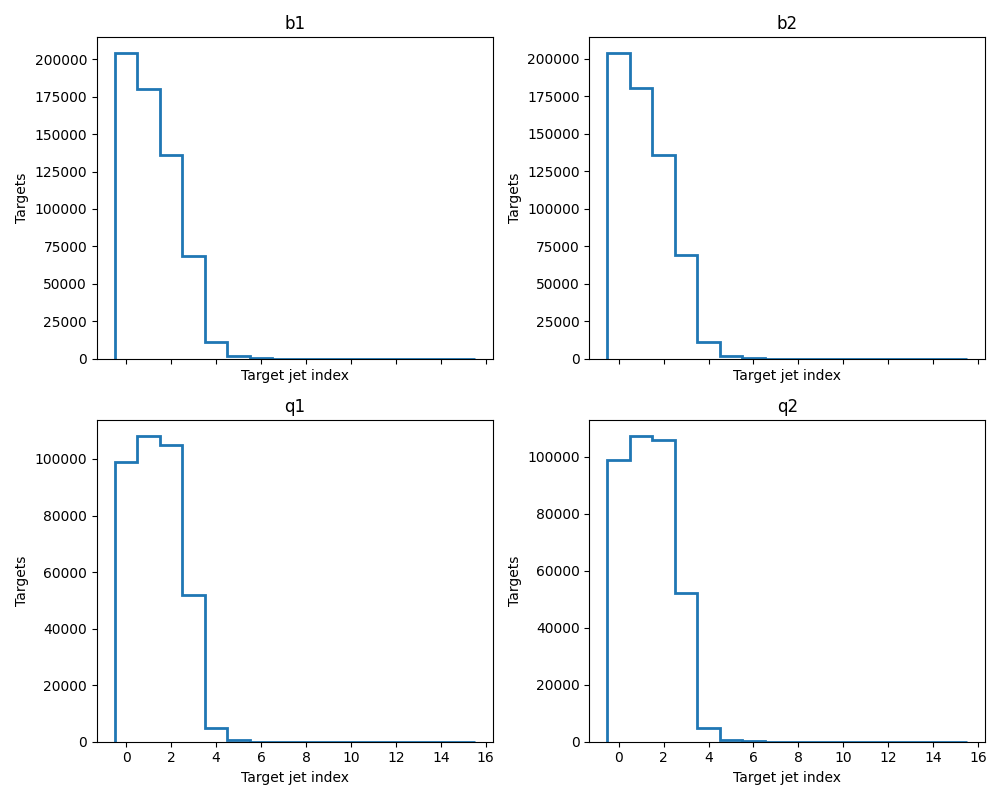

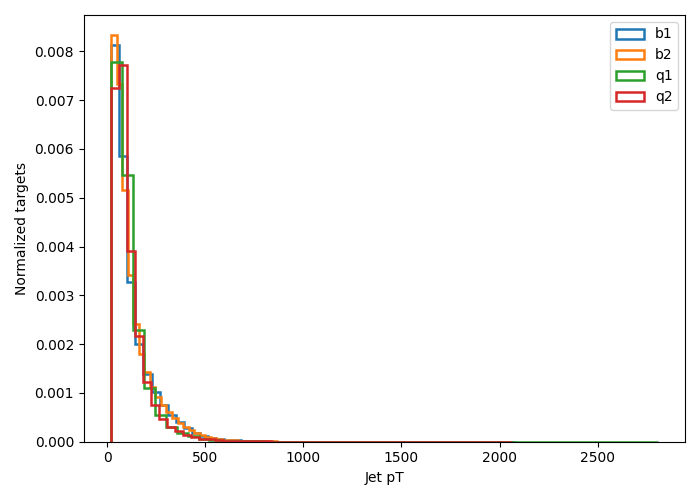

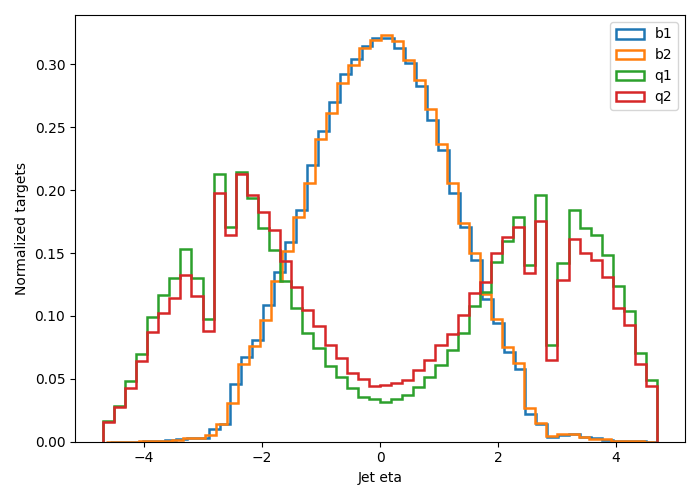

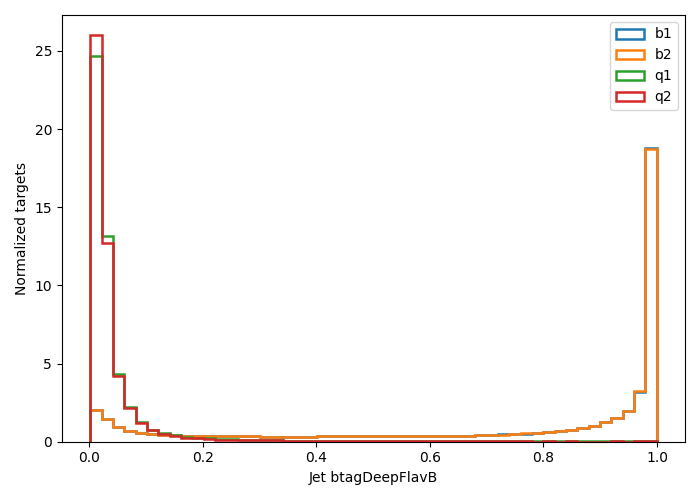

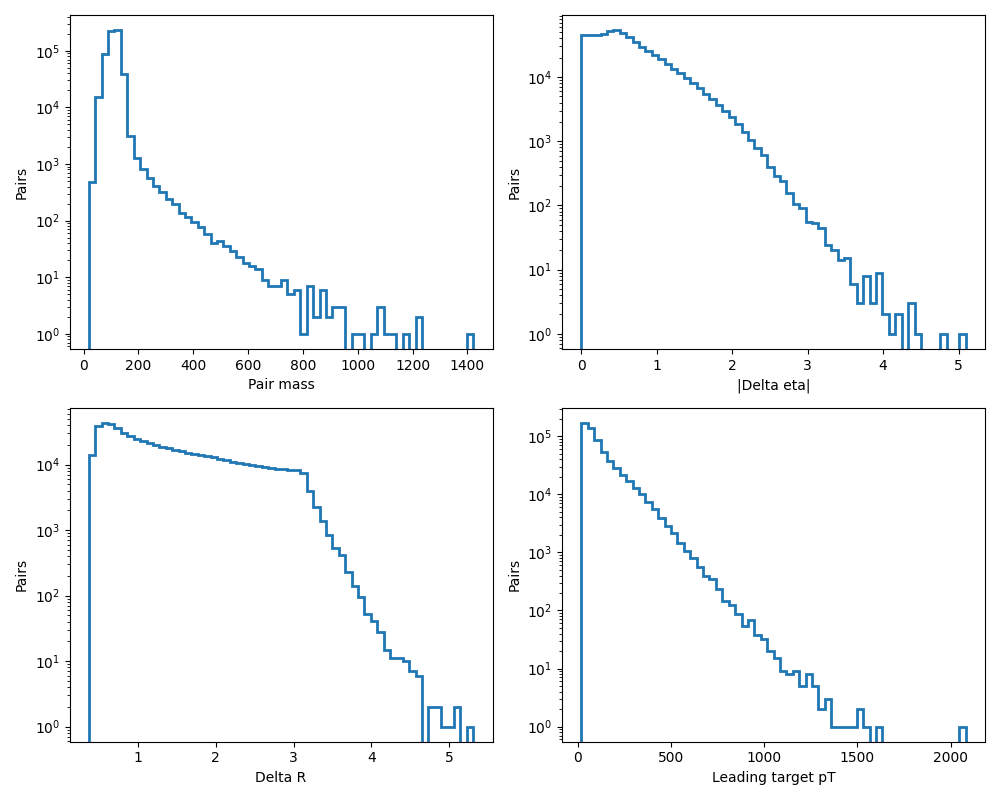

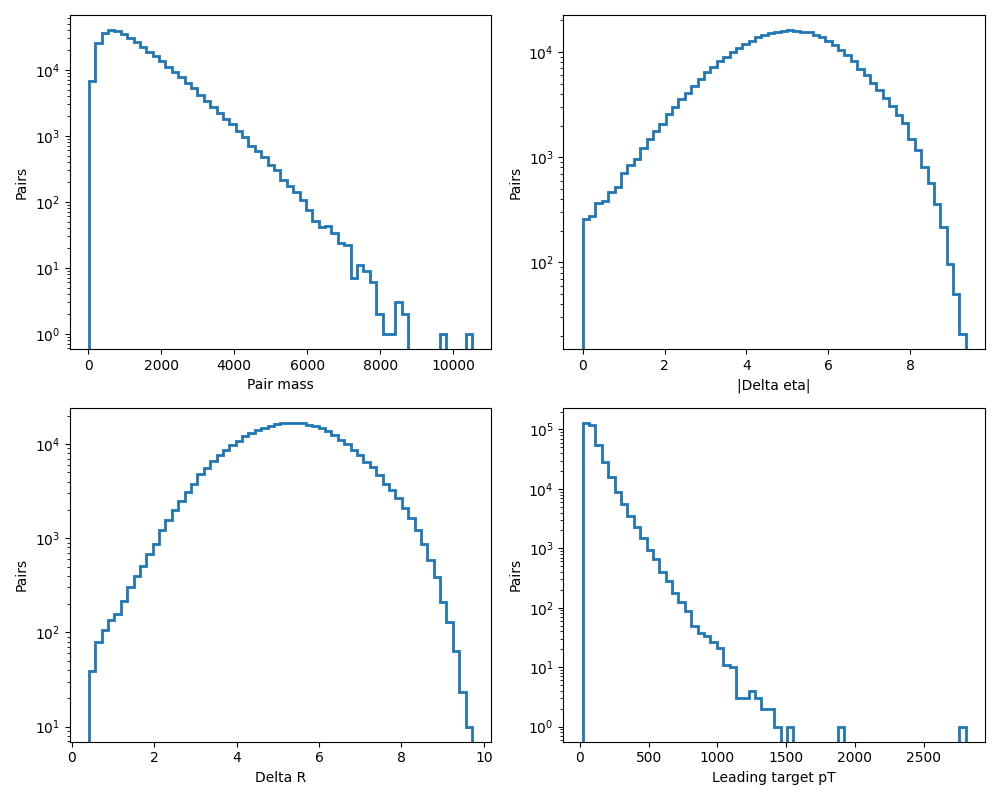

In [3]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

for name in [
    'n_spanetjets.png',
    'target_completeness.png',
    'target_indices.png',
    'target_pt.png',
    'target_eta.png',
    'target_btag.png',
    'higgs_bb_pair_kinematics.png',
    'vbf_pair_kinematics.png',
]:
    display(Image(filename=str(PLOT_DIR / name)))

In [4]:
# Quick numerical cross-checks for the two pair systems.
hhb = pair_kinematics(data, 'b1', 'b2')
vbf = pair_kinematics(data, 'q1', 'q2')

for label, kin in [('HH bb', hhb), ('VBF', vbf)]:
    print(label)
    for key in ['mass', 'abs_deta', 'dr', 'pt1', 'pt2']:
        values = kin[key]
        print(f"  {key:8s}: mean={values.mean():8.3f}, median={float(__import__('numpy').median(values)):8.3f}, n={len(values)}")

HH bb
  mass    : mean= 110.025, median= 110.674, n=602116
  abs_deta: mean=   0.633, median=   0.532, n=602116
  dr      : mean=   1.414, median=   1.203, n=602116
  pt1     : mean= 124.933, median=  86.538, n=602116
  pt2     : mean= 124.706, median=  86.410, n=602116
VBF
  mass    : mean=1315.647, median=1088.403, n=369327
  abs_deta: mean=   4.913, median=   4.969, n=369327
  dr      : mean=   5.295, median=   5.309, n=369327
  pt1     : mean= 111.134, median=  84.232, n=369327
  pt2     : mean= 111.185, median=  83.991, n=369327


## Optional raw parquet check

Use this when you want to inspect individual events directly from the reduced parquet and see which jets received `b1`, `b2`, `q1`, and `q2` labels.

In [5]:
from convert_hh_bbtautau_parquet import build_dataset, load_chunks
from validate_hh_bbtautau_truth import summarize, print_event_dump

PARQUET = Path('/local/norman/UHHAnalysis/SPANet/22pre_v14/hh_vbf_hbb_htt_kv1_k2v1_kl1_madgraph/nominal/calib__default/sel__default/red__default/prod24/events_0.parquet')
chunks = load_chunks([PARQUET], max_events=2000)
small = build_dataset(
    chunks,
    max_jets=16,
    source_collection='SPANetJet',
    hhb_dr=0.4,
    vbf_truth='genjet',
    lhe_to_gen_dr=0.4,
    gen_to_reco_dr=0.3,
    use_overlap_cleaning=True,
)
summarize(small)
print_event_dump(chunks, small, n_events=10, source_collection='SPANetJet')

Dataset summary
  events: 2000
  max_jets: 16
  mean_jets: 3.48
  min/max jets: 2/8
  higgs_bb complete: 1142/2000 (57.10%)
  vbf complete: 768/2000 (38.40%)
  both complete: 380/2000 (19.00%)
  all four targets distinct: 380/2000 (19.00%)
Process types
  1: 2000
Feature checks
  mass: finite 6950/6950 (100.00%)
  pt: finite 6950/6950 (100.00%)
  eta: finite 6950/6950 (100.00%)
  phi: finite 6950/6950 (100.00%)
  btagDeepFlavB: finite 6950/6950 (100.00%)
Event dumps
  event 0 from events_0.parquet (SPANetJet)
    targets: b1=-1, b2=-1, q1=-1, q2=-1
    00    pt=   53.74 eta=  0.325 phi= -1.321 mass=   9.17 btag=  0.7847
    01    pt=   29.25 eta= -1.247 phi= -1.191 mass=   7.56 btag=  0.0474
    02    pt=   20.72 eta= -2.027 phi= -2.216 mass=   2.89 btag=  0.2314
  event 1 from events_0.parquet (SPANetJet)
    targets: b1=-1, b2=-1, q1=-1, q2=-1
    00    pt=   72.92 eta= -0.815 phi=  2.778 mass=  13.50 btag=  0.0669
    01    pt=   52.58 eta= -0.675 phi= -2.595 mass=  11.49 btag=  0.0